<a href="https://colab.research.google.com/github/AnjinkLaCoding/ClassificationThenClustering-Method/blob/main/FinalCodingDataMining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install shap

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
TRAIN_PATH = "obesity_train.csv"
TEST_PATH = "obesity_test.csv"
TARGET_COL = "NObeyesdad"
REQUIRED_NUMERIC_COLS = ["Height", "Weight"]

In [ ]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

if TARGET_COL not in train_df.columns:
    raise ValueError(f"Training data must include the target column {TARGET_COL!r}.")

required_features = set(REQUIRED_NUMERIC_COLS)
missing_train_cols = sorted(required_features.difference(train_df.columns))
missing_test_cols = sorted(required_features.difference(test_df.columns))
if missing_train_cols:
    raise ValueError(f"Training data is missing required column(s): {missing_train_cols}")
if missing_test_cols:
    raise ValueError(f"Test data is missing required column(s): {missing_test_cols}")

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
display(train_df.head())

Train shape: (1193, 17)
Test shape:  (918, 17)


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,23.000000,Female,1.644161,84.340406,no,yes,2.177243,3.000000,no,no,2.715572,yes,2.230109,0.070897,Sometimes,Public_Transportation,Obesity_Type_I
1,22.000000,Male,1.650000,80.000000,no,no,2.000000,3.000000,no,no,2.000000,yes,3.000000,2.000000,Sometimes,Walking,Overweight_Level_II
2,20.670975,Female,1.509408,64.852953,no,no,2.294067,3.209508,no,no,2.000000,yes,1.103088,1.261043,Sometimes,Public_Transportation,Overweight_Level_II
3,23.000000,Male,1.706525,90.500055,no,yes,2.000000,3.000000,no,no,1.530493,yes,0.967627,1.000000,Sometimes,Public_Transportation,Obesity_Type_I
4,27.000000,Male,1.800000,87.000000,Frequently,no,3.000000,3.000000,no,no,2.000000,no,2.000000,0.000000,Sometimes,Walking,Overweight_Level_I


In [ ]:
def summarize_dataframe(df, name):
    summary = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "unique": df.nunique(dropna=False),
    })
    print(f"{name} shape: {df.shape}")
    display(summary)

summarize_dataframe(train_df, "Train")
summarize_dataframe(test_df, "Test")

Train shape: (1193, 17)


,dtype,missing,missing_pct,unique
Age,float64,0,0.0,711
Gender,object,0,0.0,2
Height,float64,0,0.0,794
Weight,float64,0,0.0,744
CALC,object,0,0.0,3
FAVC,object,0,0.0,2
FCVC,float64,0,0.0,462
NCP,float64,0,0.0,410
SCC,object,0,0.0,2
SMOKE,object,0,0.0,2


Test shape: (918, 17)


,dtype,missing,missing_pct,unique
Age,float64,0,0.0,712
Gender,object,0,0.0,2
Height,float64,0,0.0,818
Weight,float64,0,0.0,821
CALC,object,0,0.0,4
FAVC,object,0,0.0,2
FCVC,float64,0,0.0,360
NCP,float64,0,0.0,231
SCC,object,0,0.0,2
SMOKE,object,0,0.0,2


What is the unknown class?

In [ ]:
UnknownClass = list(set(test_df['NObeyesdad'].unique()).difference(set(train_df['NObeyesdad'].unique())))
print(UnknownClass)

['Obesity_Type_III', 'Obesity_Type_II']


We decided to add BMI to the dataframe as obesity level usually determined by ones BMI.

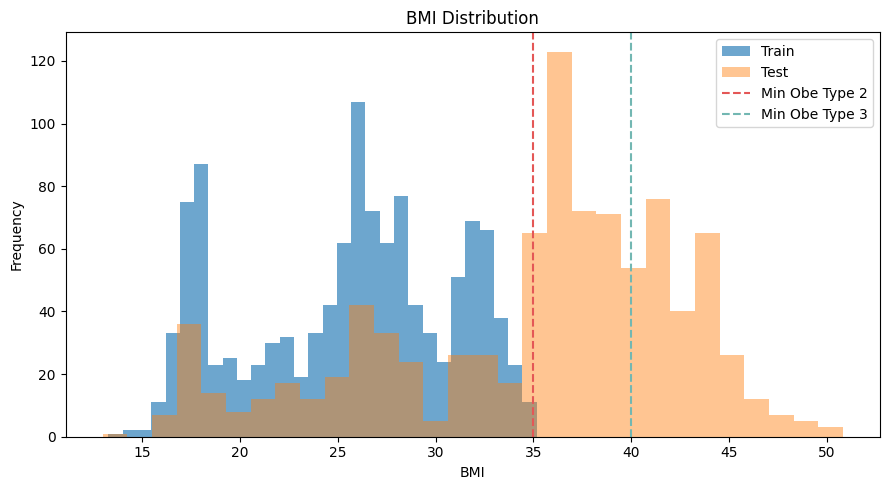

,count,mean,std,min,25%,50%,75%,max
Height,1193.0,1.692144,0.094298,1.450000,1.620000,1.700000,1.760000,1.975663
Weight,1193.0,73.541252,17.641924,39.000000,59.243506,75.093569,85.000000,121.657979
BMI,1193.0,25.577377,5.294804,13.291588,21.303949,26.214876,29.429311,35.171095


In [ ]:
def compute_bmi(df):
    height = pd.to_numeric(df["Height"], errors="coerce")
    weight = pd.to_numeric(df["Weight"], errors="coerce")
    return weight / (height ** 2)

train_df = train_df.copy()
test_df = test_df.copy()
train_df["BMI"] = compute_bmi(train_df)
test_df["BMI"] = compute_bmi(test_df)

fig, ax = plt.subplots(figsize=(9, 5))
train_df["BMI"].plot(kind="hist", bins=30, alpha=0.65, ax=ax, label="Train")
test_df["BMI"].plot(kind="hist", bins=30, alpha=0.45, ax=ax, label="Test")
ax.axvline(35, color="#e45756", linestyle="--", label="Min Obe Type 2") #Minimun BMI for obesity type 2
ax.axvline(40, color="#72b7b2", linestyle="--", label="Min Obe Type 3") #Minimum BMI for obesity type 3
ax.set_title("BMI Distribution")
ax.set_xlabel("BMI")
ax.legend()
plt.tight_layout()
plt.show()

display(train_df[["Height", "Weight", "BMI"]].describe().T)

In [ ]:
print(train_df.head())

         Age  Gender    Height     Weight        CALC FAVC      FCVC  \
0  23.000000  Female  1.644161  84.340406          no  yes  2.177243   
1  22.000000    Male  1.650000  80.000000          no   no  2.000000   
2  20.670975  Female  1.509408  64.852953          no   no  2.294067   
3  23.000000    Male  1.706525  90.500055          no  yes  2.000000   
4  27.000000    Male  1.800000  87.000000  Frequently   no  3.000000   

        NCP SCC SMOKE      CH2O family_history_with_overweight       FAF  \
0  3.000000  no    no  2.715572                            yes  2.230109   
1  3.000000  no    no  2.000000                            yes  3.000000   
2  3.209508  no    no  2.000000                            yes  1.103088   
3  3.000000  no    no  1.530493                            yes  0.967627   
4  3.000000  no    no  2.000000                             no  2.000000   

        TUE       CAEC                 MTRANS           NObeyesdad        BMI  
0  0.070897  Sometimes  Public

Preprocessing

In [ ]:
#To split the features and target column
def split_features(df, target_col=TARGET_COL):
    if target_col not in df.columns:
        return df.copy(), None
    return df.drop(columns=[target_col]).copy(), df[target_col].copy()

#To check if both train and test data have the same columns
def align_feature(train_features, test_features):
    missing_in_test = sorted(set(train_features.columns).difference(test_features.columns))
    extra_in_test = sorted(set(test_features.columns).difference(train_features.columns))
    if missing_in_test:
        raise ValueError(f"Test data is missing model feature column(s): {missing_in_test}")
    if extra_in_test:
        print(f"Ignoring extra test column(s) not used by the model: {extra_in_test}")
    return test_features.loc[:, train_features.columns].copy()

#Preparing our dataset for the xgboost
def prepare_xgb_features(df, category_levels=None):
    prepared = df.copy()
    category_cols = prepared.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    numeric_cols = [col for col in prepared.columns if col not in category_cols]

    #numerical columns stay numerical
    for col in numeric_cols:
        prepared[col] = pd.to_numeric(prepared[col], errors="coerce")

    #Category level is used to store the unique value of each columns
    #The columns name as the key, and the unique value as the value to the dictionary
    #Example: {"color": ["blue", "green", "red"]}
    #When encounter unknown category (unique value), that value will automatically turn into N/A
    if category_levels is None:
        category_levels = {}
        for col in category_cols:
            prepared[col] = prepared[col].astype("category")
            category_levels[col] = prepared[col].cat.categories
    else:
        for col, levels in category_levels.items():
            if col in prepared.columns:
                prepared[col] = pd.Categorical(prepared[col], categories=levels)

    return prepared, category_levels


X_all_raw, y_all_labels = split_features(train_df)
X_test_raw, y_test_labels = split_features(test_df)
X_test_raw = align_feature(X_all_raw, X_test_raw)

label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(y_all_labels)
class_names = label_encoder.classes_
print("Model features:", list(X_all_raw.columns))
print("Classes:", list(class_names))

Model features: ['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'MTRANS', 'BMI']
Classes: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Overweight_Level_I', 'Overweight_Level_II']


Build model

In [ ]:
def build_model():
    return xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        enable_categorical=True,
        tree_method="hist",
        eval_metric="mlogloss",
        verbosity=0,
        random_state=RANDOM_STATE,
    )

Stratified Validation

,model,accuracy,macro_f1,weighted_f1,precision_macro,recall_macro
0,XGBoost,0.9874,0.9869,0.9874,0.987,0.9871


XGBoost validation report
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      1.00      0.99        44
      Normal_Weight       0.98      0.98      0.98        46
     Obesity_Type_I       1.00      1.00      1.00        56
 Overweight_Level_I       1.00      0.96      0.98        47
Overweight_Level_II       0.98      1.00      0.99        46

           accuracy                           0.99       239
          macro avg       0.99      0.99      0.99       239
       weighted avg       0.99      0.99      0.99       239



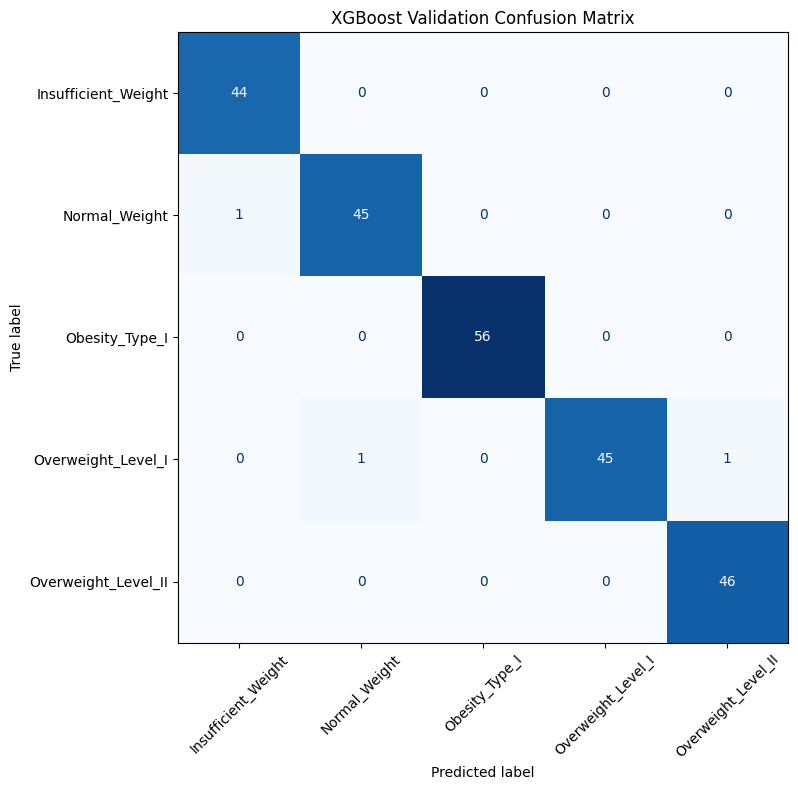

In [ ]:
#avoiding a lopsided split — for example, without it,
#a rare class with only a few samples could end up entirely in the training set
#and be absent from validation, making evaluation unreliable.
def stratified_validation_split(X, y, test_size=0.2):
    class_counts = pd.Series(y).value_counts()
    if len(class_counts) < 2:
        raise ValueError("At least two target classes are required for classification.")
    if class_counts.min() < 2:
        raise ValueError(
            "Stratified validation requires at least two rows in every class. "
            f"Class counts: {class_counts.to_dict()}"
        )
    return train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=y,
    )

#x_all_raw and y_all is from the train_df
X_train_raw, X_val_raw, y_train, y_val = stratified_validation_split(X_all_raw, y_all)
X_train_xgb, category_levels = prepare_xgb_features(X_train_raw)
X_val_xgb, _ = prepare_xgb_features(X_val_raw, category_levels) #'_' means discarding the value

xgb_val_model = build_model()
xgb_val_model.fit(X_train_xgb, y_train)
xgb_val_proba = xgb_val_model.predict_proba(X_val_xgb)
xgb_val_pred = xgb_val_proba.argmax(axis=1)


validation_scores = pd.DataFrame([
    {
        "model": "XGBoost",
        "accuracy": accuracy_score(y_val, xgb_val_pred),
        "macro_f1": f1_score(y_val, xgb_val_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_val, xgb_val_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(y_val, xgb_val_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_val, xgb_val_pred, average="macro", zero_division=0),
    },
])
display(validation_scores.round(4))

print("XGBoost validation report")
class_indices = np.arange(len(class_names))
print(classification_report(y_val, xgb_val_pred, labels=class_indices, target_names=class_names, zero_division=0))

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay.from_predictions(
    y_val,
    xgb_val_pred,
    labels=class_indices,
    display_labels=class_names,
    xticks_rotation=45,
    cmap="Blues",
    ax=ax,
    colorbar=False,
)
ax.set_title("XGBoost Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
def tune_confidence_threshold(y_true, probabilities, min_coverage=0.60):
    rows = []
    predicted = probabilities.argmax(axis=1)
    confidence = probabilities.max(axis=1)
    for threshold in np.round(np.arange(0.50, 0.971, 0.01), 2):
        confident = confidence >= threshold
        coverage = confident.mean()
        if confident.any():
            confident_accuracy = accuracy_score(y_true[confident], predicted[confident])
            confident_macro_f1 = f1_score(y_true[confident], predicted[confident], average="macro", zero_division=0)
        else:
            confident_accuracy = np.nan
            confident_macro_f1 = np.nan
        rows.append({
            "threshold": threshold,
            "coverage": coverage,
            "uncertain_rate": 1 - coverage,
            "confident_accuracy": confident_accuracy,
            "confident_macro_f1": confident_macro_f1,
        })

    threshold_df = pd.DataFrame(rows)
    candidates = threshold_df[threshold_df["coverage"] >= min_coverage].dropna()
    if candidates.empty:
        best = threshold_df.dropna().sort_values(
            ["confident_accuracy", "coverage", "threshold"], ascending=[False, False, True]
        ).iloc[0]
    else:
        best = candidates.sort_values(
            ["confident_accuracy", "confident_macro_f1", "coverage", "threshold"],
            ascending=[False, False, False, True],
        ).iloc[0]
    return float(best["threshold"]), threshold_df

confidence_threshold, threshold_table = tune_confidence_threshold(y_val, xgb_val_proba)
print(f"Selected confidence threshold: {confidence_threshold:.2f}")
display(threshold_table.iloc[::5].round(4))

Selected confidence threshold: 0.97


,threshold,coverage,uncertain_rate,confident_accuracy,confident_macro_f1
0,0.50,1.0000,0.0000,0.9874,0.9869
5,0.55,1.0000,0.0000,0.9874,0.9869
10,0.60,1.0000,0.0000,0.9874,0.9869
15,0.65,1.0000,0.0000,0.9874,0.9869
20,0.70,1.0000,0.0000,0.9874,0.9869
25,0.75,1.0000,0.0000,0.9874,0.9869
30,0.80,0.9916,0.0084,0.9873,0.9867
35,0.85,0.9874,0.0126,0.9915,0.9912
40,0.90,0.9833,0.0167,0.9915,0.9911
45,0.95,0.9749,0.0251,0.9914,0.9910


Test labels excluded from model evaluation because they were not present in training: ['Obesity_Type_II', 'Obesity_Type_III']
Known-label test accuracy: 0.9630
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.98      0.98        54
      Normal_Weight       0.97      0.98      0.97        57
     Obesity_Type_I       1.00      0.99      0.99        70
 Overweight_Level_I       0.95      0.91      0.93        58
Overweight_Level_II       0.92      0.95      0.93        58

           accuracy                           0.96       297
          macro avg       0.96      0.96      0.96       297
       weighted avg       0.96      0.96      0.96       297



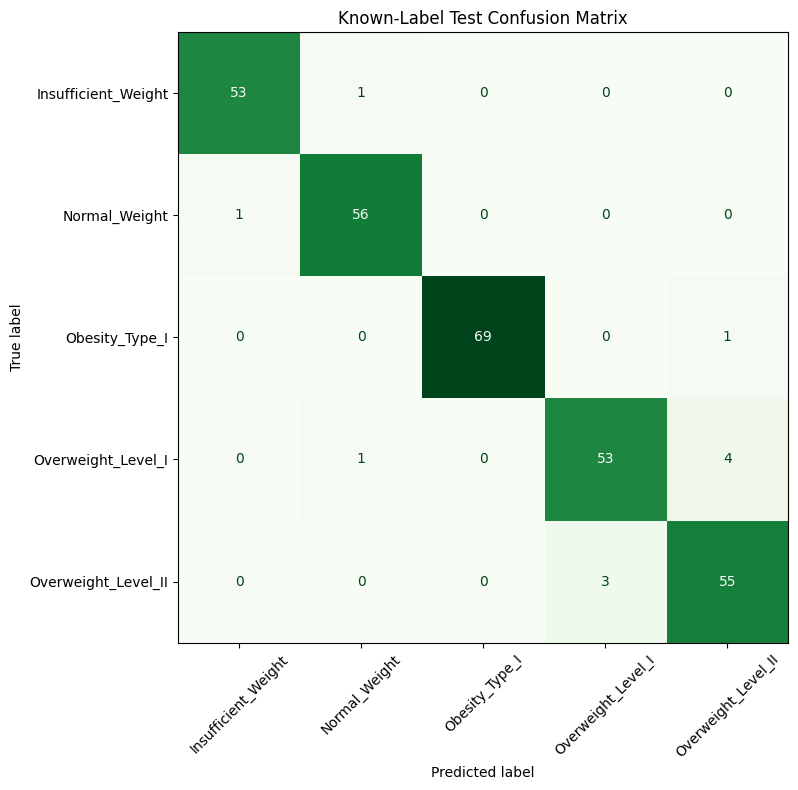

In [ ]:
X_all_xgb, final_category_levels = prepare_xgb_features(X_all_raw)
X_test_xgb, _ = prepare_xgb_features(X_test_raw, final_category_levels)

final_model = build_model()
final_model.fit(X_all_xgb, y_all)

test_proba = final_model.predict_proba(X_test_xgb)
test_pred_encoded = test_proba.argmax(axis=1)
test_pred_labels = label_encoder.inverse_transform(test_pred_encoded)
test_confidence = test_proba.max(axis=1)

if y_test_labels is not None:
    known_test_mask = y_test_labels.isin(class_names)
    unknown_test_labels = sorted(set(y_test_labels.dropna().unique()).difference(set(class_names)))
    if unknown_test_labels:
        print("Test labels excluded from model evaluation because they were not present in training:", unknown_test_labels)
    if known_test_mask.any():
        y_test_known = label_encoder.transform(y_test_labels[known_test_mask])
        y_pred_known = test_pred_encoded[known_test_mask.to_numpy()]
        print(f"Known-label test accuracy: {accuracy_score(y_test_known, y_pred_known):.4f}")
        print(classification_report(y_test_known, y_pred_known, labels=class_indices, target_names=class_names, zero_division=0))
        fig, ax = plt.subplots(figsize=(9, 8))
        ConfusionMatrixDisplay.from_predictions(
            y_test_known,
            y_pred_known,
            labels=class_indices,
            display_labels=class_names,
            xticks_rotation=45,
            cmap="Greens",
            ax=ax,
            colorbar=False,
        )
        ax.set_title("Known-Label Test Confusion Matrix")
        plt.tight_layout()
        plt.show()
    else:
        print("No test labels overlap with the training classes, so test metrics were skipped.")
else:
    print("Test labels are not available; generated predictions only.")

Below quite good 1

In [ ]:
HIGHEST_KNOWN_CLASS = "Obesity_Type_I"
OVERRIDE_CLASS_NAMES = ["Obesity_Type_II", "Obesity_Type_III"]
N_CLUSTERS = 3  # Type_I, Type_II, Type_III

# Features used for clustering — full feature set used by the classifier
# plus BMI, so the cluster geometry reflects the same space the model uses.
CLUSTER_FEATURES = [col for col in X_test_xgb.columns if col != "BMI"] + ["BMI"]


def cluster_ceiling_rows(
    test_features_xgb,
    test_bmi,
    base_labels,
    confidence,
    threshold,
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
):
    """
    Isolate rows predicted as Obesity_Type_I, cluster them into n_clusters
    groups, then map clusters to Type_I / Type_II / Type_III by ascending
    mean BMI. Returns final labels and prediction sources.
    """
    final_labels = np.array(base_labels, dtype=object)
    sources = np.where(
        confidence >= threshold, "classifier", "classifier_low_confidence"
    ).astype(object)

    # Identify ceiling rows
    ceiling_mask = final_labels == HIGHEST_KNOWN_CLASS
    ceiling_idx = np.where(ceiling_mask)[0]

    if len(ceiling_idx) < n_clusters:
        print(
            f"Warning: only {len(ceiling_idx)} ceiling rows found — "
            "skipping clustering override, not enough samples."
        )
        return final_labels, sources

    # Build numeric feature matrix for clustering
    # Categorical columns are ordinally encoded via their category codes
    ceiling_features = test_features_xgb.iloc[ceiling_idx].copy()
    numeric_matrix = np.zeros((len(ceiling_idx), len(CLUSTER_FEATURES)))
    for i, col in enumerate(CLUSTER_FEATURES):
        if col in ceiling_features.columns:
            col_data = ceiling_features[col]
            if hasattr(col_data, "cat"):
                numeric_matrix[:, i] = col_data.cat.codes.to_numpy(dtype=float)
            else:
                numeric_matrix[:, i] = pd.to_numeric(col_data, errors="coerce").to_numpy(dtype=float)

    # Impute any NaNs with column means before scaling
    col_means = np.nanmean(numeric_matrix, axis=0)
    nan_mask = np.isnan(numeric_matrix)
    numeric_matrix[nan_mask] = np.take(col_means, np.where(nan_mask)[1])

    scaler = StandardScaler()
    scaled_matrix = scaler.fit_transform(numeric_matrix)

    # Cluster
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    cluster_labels = kmeans.fit_predict(scaled_matrix)

    # Map clusters to obesity classes by ascending mean BMI
    bmi_ceiling = test_bmi.iloc[ceiling_idx].to_numpy()
    cluster_mean_bmi = {
        c: bmi_ceiling[cluster_labels == c].mean()
        for c in range(n_clusters)
    }
    sorted_clusters = sorted(cluster_mean_bmi, key=cluster_mean_bmi.get)
    cluster_to_class = {
        sorted_clusters[0]: "Obesity_Type_I",
        sorted_clusters[1]: "Obesity_Type_II",
        sorted_clusters[2]: "Obesity_Type_III",
    }

    print("Cluster → class mapping (by mean BMI):")
    for c, cls in cluster_to_class.items():
        print(f"  Cluster {c}: mean BMI = {cluster_mean_bmi[c]:.2f} → {cls}")

    # Apply relabeling
    for pos, original_idx in enumerate(ceiling_idx):
        assigned_class = cluster_to_class[cluster_labels[pos]]
        if assigned_class != HIGHEST_KNOWN_CLASS:
            final_labels[original_idx] = assigned_class
            sources[original_idx] = "clustering_override"

    return final_labels, sources


final_pred_labels, prediction_sources = cluster_ceiling_rows(
    X_test_xgb,
    test_df["BMI"],
    test_pred_labels,
    test_confidence,
    confidence_threshold,
)

source_summary = (
    pd.Series(prediction_sources)
    .value_counts()
    .rename_axis("prediction_source")
    .reset_index(name="rows")
)
display(source_summary)

# Evaluation over the full label set including the two override classes
if y_test_labels is not None:
    full_label_set = list(dict.fromkeys(list(class_names) + OVERRIDE_CLASS_NAMES))
    labeled_mask = y_test_labels.notna().to_numpy()
    if labeled_mask.any():
        y_true_full = y_test_labels[labeled_mask].astype(str).to_numpy()
        y_pred_full = np.asarray(final_pred_labels, dtype=object)[labeled_mask]
        print(
            f"Full-label-set test accuracy (with clustering override): "
            f"{accuracy_score(y_true_full, y_pred_full):.4f}"
        )
        print(
            "Note: Type II and III recall depends on cluster separation quality.\n"
        )
        print(classification_report(
            y_true_full, y_pred_full, labels=full_label_set, zero_division=0
        ))

Cluster → class mapping (by mean BMI):
  Cluster 1: mean BMI = 35.08 → Obesity_Type_I
  Cluster 2: mean BMI = 36.17 → Obesity_Type_II
  Cluster 0: mean BMI = 42.24 → Obesity_Type_III


,prediction_source,rows
0,clustering_override,591
1,classifier,311
2,classifier_low_confidence,16


Full-label-set test accuracy (with clustering override): 0.8900
Note: Type II and III recall depends on cluster separation quality.

                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.98      0.98        54
      Normal_Weight       0.97      0.98      0.97        57
     Obesity_Type_I       0.39      0.56      0.46        70
 Overweight_Level_I       0.95      0.91      0.93        58
Overweight_Level_II       0.92      0.95      0.93        58
    Obesity_Type_II       0.89      0.80      0.84       297
   Obesity_Type_III       1.00      1.00      1.00       324

           accuracy                           0.89       918
          macro avg       0.87      0.88      0.87       918
       weighted avg       0.91      0.89      0.90       918



Second altyernative to clustering

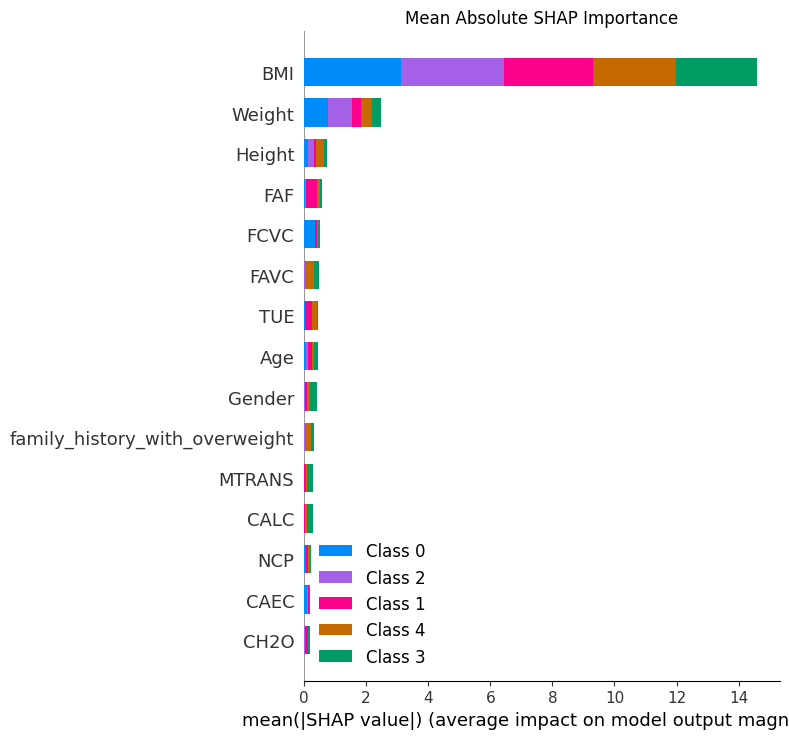

<Figure size 900x600 with 0 Axes>

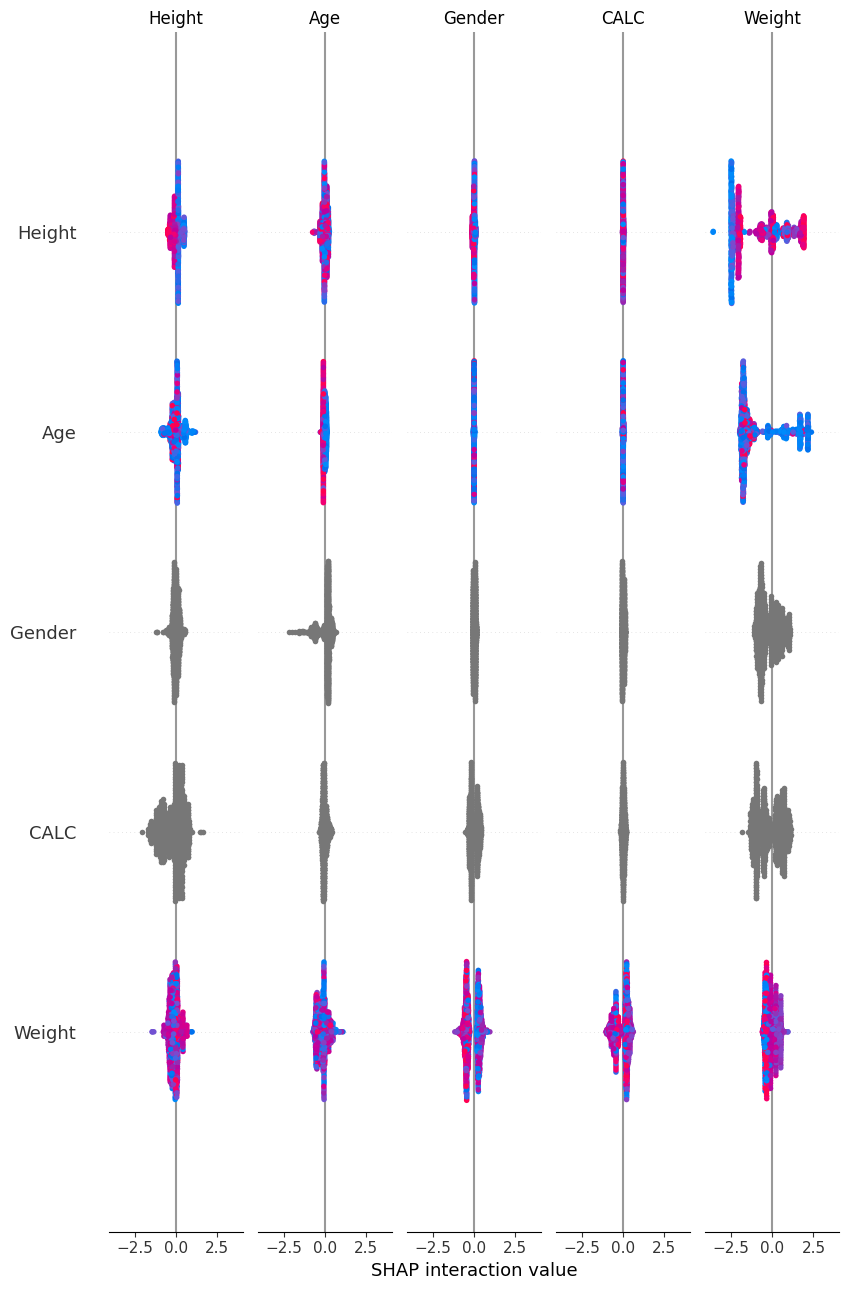

,xgb_importance,mean_abs_shap
BMI,0.43877,2.92045
Weight,0.15036,0.49524
Height,0.05785,0.15063
FAF,0.02407,0.11562
FCVC,0.01953,0.10275
FAVC,0.03225,0.09664
TUE,0.02234,0.09268
Age,0.01898,0.09133
Gender,0.01627,0.08135
family_history_with_overweight,0.03477,0.06187


In [ ]:
def mean_abs_shap_by_feature(shap_values, feature_names):
    if isinstance(shap_values, list):
        arr = np.stack(shap_values, axis=-1)
    else:
        arr = np.asarray(shap_values)

    if arr.ndim == 2:
        mean_abs = np.abs(arr).mean(axis=0)
    elif arr.ndim == 3:
        if arr.shape[1] == len(feature_names):
            mean_abs = np.abs(arr).mean(axis=(0, 2))
        elif arr.shape[2] == len(feature_names):
            mean_abs = np.abs(arr).mean(axis=(0, 1))
        else:
            raise ValueError(f"Could not align SHAP array shape {arr.shape} with features.")
    else:
        raise ValueError(f"Unsupported SHAP array shape: {arr.shape}")
    return pd.Series(mean_abs, index=feature_names, name="mean_abs_shap")

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_all_xgb)

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_all_xgb, plot_type="bar", show=False, max_display=15)
plt.title("Mean Absolute SHAP Importance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_all_xgb, show=False, max_display=15)
plt.tight_layout()
plt.show()

xgb_importance = pd.Series(final_model.feature_importances_, index=X_all_xgb.columns, name="xgb_importance")
shap_importance = mean_abs_shap_by_feature(shap_values, X_all_xgb.columns)
importance_comparison = pd.concat([xgb_importance, shap_importance], axis=1).sort_values("mean_abs_shap", ascending=False)
display(importance_comparison.head(15).round(5))

In [ ]:
output_df = test_df.copy()
output_df["BMI"] = test_df["BMI"]
output_df["predicted_label"] = final_pred_labels
output_df["confidence"] = test_confidence
output_df["prediction_source"] = prediction_sources

probability_df = pd.DataFrame(test_proba, columns=[f"probability_{label}" for label in class_names], index=output_df.index)
output_df = pd.concat([output_df, probability_df], axis=1)

output_df.to_csv("obesity_predictions.csv", index=False)
print(f"Saved docs with {len(output_df)} rows and {len(output_df.columns)} columns.")
display(output_df.head())

Saved docs with 918 rows and 26 columns.


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,...,NObeyesdad,BMI,predicted_label,confidence,prediction_source,probability_Insufficient_Weight,probability_Normal_Weight,probability_Obesity_Type_I,probability_Overweight_Level_I,probability_Overweight_Level_II
0,20.027764,Male,1.611434,103.175516,no,yes,2.983042,1.109956,no,no,...,Obesity_Type_II,39.733023,Obesity_Type_III,0.999316,clustering_override,0.000103,0.000143,0.999316,0.000154,0.000284
1,24.007488,Male,1.617655,100.941357,no,yes,2.871016,1.834472,no,no,...,Obesity_Type_II,38.574236,Obesity_Type_I,0.999428,classifier,0.000089,0.000063,0.999428,0.000112,0.000308
2,25.617227,Female,1.628019,108.265922,Sometimes,yes,3.000000,3.000000,no,no,...,Obesity_Type_III,40.848192,Obesity_Type_III,0.999470,clustering_override,0.000087,0.000060,0.999470,0.000177,0.000207
3,32.290160,Male,1.754956,120.098812,Sometimes,yes,2.967300,3.000000,no,no,...,Obesity_Type_II,38.994760,Obesity_Type_II,0.998604,clustering_override,0.000111,0.000074,0.998604,0.000285,0.000926
4,29.883021,Male,1.779049,112.438508,Sometimes,yes,2.065752,3.000000,no,no,...,Obesity_Type_II,35.525423,Obesity_Type_II,0.998857,clustering_override,0.000098,0.000118,0.998857,0.000250,0.000677
